# Autonomous Production Choke Controller
### Single Naturally Flowing Oil Well — Hackathon Submission

This notebook walks through the complete control workflow end to end:

1. **Simulator** — the process source (calibrated against the provided reference dataset)
2. **Open-loop step test** — process understanding across the full 0-100% choke range
3. **Dynamic model identification** — a first-order model fit to the step-test data
4. **MPC controller** — brute-force candidate evaluation with safety-constraint rejection
5. **Closed-loop scenarios A / B / C** — startup, target tracking, and infeasible-target handling
6. **Results summary** — pass/fail metrics and lessons learned

Run all cells top to bottom. Each section corresponds to one source file from the
submission codebase (`simulator.py`, `step_test_full.py`, `well_model.py`,
`controller.py`, `run_scenarios.py`, `config.py`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.optimize import curve_fit
import logging

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 4)
np.set_printoptions(precision=2, suppress=True)


## 1. Configuration — Safety Envelope & Controller Parameters
*(from `config.py`)*

Safe operating limits for WHP, FLP, BHP, derived from the full-range step test
(0–100% choke sweep) with margins applied **inward** from the observed extremes.
This gives the MPC headroom before hitting hard limits and absorbs transient
overshoot inherent to first-order dynamics after a large step change.

| Variable | Min | Max | Basis |
|---|---|---|---|
| WHP (psi) | 180 | 310 | observed [171, 319], ~9 psi margin |
| FLP (psi) | 130 | 210 | observed [120, 219], ~9-10 psi margin |
| BHP (psi) | 2600 | 3350 | observed [2560, 3366], ~0.5-1.5% margin |
| Choke (%) | 0 | 100 | hard physical limits |
| Ramp rate | — | ±5%/step | hard physical limit |


In [2]:
# ── Safety Envelope (psi) ──────────────────────────────────────────
WHP_MIN, WHP_MAX = 180.0, 310.0     # psi
FLP_MIN, FLP_MAX = 130.0, 210.0     # psi
BHP_MIN, BHP_MAX = 2600.0, 3350.0   # psi

# ── Controller Parameters ──────────────────────────────────────────
CHOKE_MIN, CHOKE_MAX = 0.0, 100.0   # %
CHOKE_RAMP_MAX = 5.0                # % — max single-step choke movement
CHOKE_RESOLUTION = 1.0              # % — MPC candidate evaluation resolution
MPC_HORIZON = 4                     # steps — prediction horizon

# ── Noise Characterization (matched to reference dataset scatter) ─
NOISE_Q_STD = 0.8      # bbl/hr
NOISE_WHP_STD = 1.2    # psi
NOISE_FLP_STD = 0.8    # psi
NOISE_BHP_STD = 3.0    # psi


def check_safety(whp, flp, bhp):
    """Check whether a set of pressure readings is within safe limits."""
    violations = []
    if whp < WHP_MIN: violations.append(f"WHP={whp:.1f} < {WHP_MIN} (min)")
    if whp > WHP_MAX: violations.append(f"WHP={whp:.1f} > {WHP_MAX} (max)")
    if flp < FLP_MIN: violations.append(f"FLP={flp:.1f} < {FLP_MIN} (min)")
    if flp > FLP_MAX: violations.append(f"FLP={flp:.1f} > {FLP_MAX} (max)")
    if bhp < BHP_MIN: violations.append(f"BHP={bhp:.1f} < {BHP_MIN} (min)")
    if bhp > BHP_MAX: violations.append(f"BHP={bhp:.1f} > {BHP_MAX} (max)")
    return len(violations) == 0, violations

print("Safety Envelope:")
print(f"  WHP: [{WHP_MIN}, {WHP_MAX}] psi")
print(f"  FLP: [{FLP_MIN}, {FLP_MAX}] psi")
print(f"  BHP: [{BHP_MIN}, {BHP_MAX}] psi")
print(f"  Choke: [{CHOKE_MIN}, {CHOKE_MAX}]%%, ramp <= {CHOKE_RAMP_MAX}%%/step")
print(f"  MPC horizon: {MPC_HORIZON} steps")


Safety Envelope:
  WHP: [180.0, 310.0] psi
  FLP: [130.0, 210.0] psi
  BHP: [2600.0, 3350.0] psi
  Choke: [0.0, 100.0]%%, ramp <= 5.0%%/step
  MPC horizon: 4 steps


## 2. Simulator — Process Source
*(from `simulator.py`)*

**Calibration note:** no live simulator was provided as promised in the problem
statement, so this simulator was calibrated directly against the reference
dataset (`Autonomous_Choke_Control_Simulated_Dataset.csv`) that *was* provided:

- Steady-state Q/WHP/FLP/BHP vs. choke were extracted from the 5 tested choke
  levels (30, 40, 45, 55, 65%) and connected with monotonic **PCHIP** interpolation
  (avoids polynomial overshoot/oscillation artifacts).
- A shut-in anchor at choke=0% was added by extrapolating the reference data's
  linear trend back to 0% (confirmed by both a linear fit and a saturating
  exponential fit, which agreed closely).
- Two anchors above the tested range (choke=80, 100%) were added using a
  tapering/saturating assumption — an explicit, documented modeling assumption
  since the reference data never tested that region.
- The transient time constant (**tau ≈ 5 hours**) was fit from the reference
  data's step-response transients (two independent segments gave 5.24h and
  4.46h; 5.0h is used).

Interface matches the problem statement: `Q, WHP, FLP, BHP = simulator.step(choke_position)`.


In [3]:
class OilWellSimulator:
    def __init__(self, seed=42):
        self.rng = np.random.default_rng(seed)

        # ---- Anchor points for steady-state curves ----
        # choke=0    : shut-in (extrapolated from reference data trend)
        # choke=30..65: taken directly from reference dataset steady states
        # choke=80,100: tapering assumption beyond tested range (documented)
        self._choke_anchor = np.array([0, 30, 40, 45, 55, 65, 80, 100], dtype=float)

        self._Q_anchor   = np.array([0.0, 93.72, 111.16, 121.00, 139.90, 155.87, 172.0, 182.0])
        self._WHP_anchor = np.array([317.5, 269.92, 259.14, 246.16, 232.37, 217.18, 196.0, 172.0])
        self._FLP_anchor = np.array([216.9, 187.89, 179.63, 174.92, 164.55, 155.28, 140.0, 120.0])
        self._BHP_anchor = np.array([3362.6, 3137.48, 3084.25, 3023.11, 2969.03, 2882.73, 2740.0, 2560.0])

        self._Q_curve   = PchipInterpolator(self._choke_anchor, self._Q_anchor)
        self._WHP_curve = PchipInterpolator(self._choke_anchor, self._WHP_anchor)
        self._FLP_curve = PchipInterpolator(self._choke_anchor, self._FLP_anchor)
        self._BHP_curve = PchipInterpolator(self._choke_anchor, self._BHP_anchor)

        # ---- Dynamics: fit from reference data step-response transients ----
        self.tau_hours = 5.0          # time constant in hours (control interval = 1 hour)
        self.dt_hours = 1.0
        self.alpha = 1 - np.exp(-self.dt_hours / self.tau_hours)  # discrete relaxation factor

        # ---- Measurement noise (std dev), matched to reference data scatter ----
        self.noise_Q = 0.8
        self.noise_WHP = 1.2
        self.noise_FLP = 0.8
        self.noise_BHP = 3.0

        # ---- State ----
        self.choke = 30.0
        Q0, WHP0, FLP0, BHP0 = self._steady_state(self.choke)
        self.Q, self.WHP, self.FLP, self.BHP = Q0, WHP0, FLP0, BHP0

    def _steady_state(self, choke_pct):
        c = np.clip(choke_pct, 0.0, 100.0)
        Q = float(self._Q_curve(c))
        WHP = float(self._WHP_curve(c))
        FLP = float(self._FLP_curve(c))
        BHP = float(self._BHP_curve(c))
        return Q, WHP, FLP, BHP

    def step(self, choke_position):
        """Advance by one control interval (1 hour) given a new choke position."""
        choke_position = float(np.clip(choke_position, 0.0, 100.0))
        self.choke = choke_position

        Q_ss, WHP_ss, FLP_ss, BHP_ss = self._steady_state(choke_position)

        # First-order relaxation toward steady state
        self.Q = self.Q + self.alpha * (Q_ss - self.Q)
        self.WHP = self.WHP + self.alpha * (WHP_ss - self.WHP)
        self.FLP = self.FLP + self.alpha * (FLP_ss - self.FLP)
        self.BHP = self.BHP + self.alpha * (BHP_ss - self.BHP)

        # Measurement noise
        Q_meas = max(self.Q + self.rng.normal(0, self.noise_Q), 0.0)
        WHP_meas = self.WHP + self.rng.normal(0, self.noise_WHP)
        FLP_meas = self.FLP + self.rng.normal(0, self.noise_FLP)
        BHP_meas = self.BHP + self.rng.normal(0, self.noise_BHP)

        return Q_meas, WHP_meas, FLP_meas, BHP_meas

    def reset(self, choke_position=30.0):
        self.choke = choke_position
        Q0, WHP0, FLP0, BHP0 = self._steady_state(choke_position)
        self.Q, self.WHP, self.FLP, self.BHP = Q0, WHP0, FLP0, BHP0
        return self.Q, self.WHP, self.FLP, self.BHP


# Convenience module-level instance, matching `simulator.step(...)` usage
simulator = OilWellSimulator()
print("Simulator ready.")


Simulator ready.


In [4]:
# Quick sanity check: step through a few choke positions
sim_check = OilWellSimulator()
for choke in [10, 10, 10, 30, 30, 30, 30, 60, 60, 60, 60, 90, 90, 90, 90]:
    Q, WHP, FLP, BHP = sim_check.step(choke)
    print(f"choke={choke:5.1f}%  Q={Q:7.2f} bbl/hr  WHP={WHP:7.1f} psi  "
          f"FLP={FLP:7.1f} psi  BHP={BHP:7.1f} psi")


choke= 10.0%  Q=  83.87 bbl/hr  WHP=  274.0 psi  FLP=  191.9 psi  BHP= 3165.6 psi
choke= 10.0%  Q=  73.80 bbl/hr  WHP=  278.0 psi  FLP=  194.1 psi  BHP= 3182.6 psi
choke= 10.0%  Q=  68.58 bbl/hr  WHP=  282.1 psi  FLP=  197.0 psi  BHP= 3202.8 psi
choke= 30.0%  Q=  73.20 bbl/hr  WHP=  282.1 psi  FLP=  195.2 psi  BHP= 3186.5 psi
choke= 30.0%  Q=  77.17 bbl/hr  WHP=  277.6 psi  FLP=  194.2 psi  BHP= 3179.5 psi
choke= 30.0%  Q=  79.78 bbl/hr  WHP=  276.3 psi  FLP=  193.5 psi  BHP= 3171.6 psi
choke= 30.0%  Q=  82.09 bbl/hr  WHP=  275.4 psi  FLP=  192.1 psi  BHP= 3166.9 psi
choke= 60.0%  Q=  94.72 bbl/hr  WHP=  267.1 psi  FLP=  187.6 psi  BHP= 3121.6 psi
choke= 60.0%  Q= 103.78 bbl/hr  WHP=  258.0 psi  FLP=  181.7 psi  BHP= 3091.1 psi
choke= 60.0%  Q= 112.11 bbl/hr  WHP=  251.8 psi  FLP=  176.7 psi  BHP= 3060.8 psi
choke= 60.0%  Q= 119.36 bbl/hr  WHP=  248.4 psi  FLP=  173.6 psi  BHP= 3036.0 psi
choke= 90.0%  Q= 129.66 bbl/hr  WHP=  236.3 psi  FLP=  166.9 psi  BHP= 2965.9 psi
choke= 90.0%  Q=

## 3. Open-Loop Step Test — Process Understanding
*(from `step_test_full.py`)*

A staircase schedule sweeps the full 0–100% choke range using up-steps,
down-steps, and reversals, so the identified model captures behavior across
the full operating range without direction bias. Each level is held for
**20 hours** (4×tau, >98% settled) to give a clean steady-state read.


In [5]:
# (choke_level, hold_hours)
SCHEDULE = [
    (0,  20),   # shut-in anchor
    (20, 20),
    (30, 20),   # matches simulator anchor at 30%
    (40, 20),
    (45, 20),
    (55, 20),
    (65, 20),   # top of reference dataset range
    (80, 20),
    (100, 20),  # max choke
    (70, 20),   # down-step
    (50, 20),
    (25, 20),
    (45, 20),   # reversal up (repeat for consistency check)
    (75, 20),
    (35, 20),   # reversal down
    (55, 20),   # reversal up (repeat)
    (10, 20),   # deep down-step
    (90, 20),   # large up-step
    (60, 20),   # moderate down-step
]

def run_step_test(seed=42):
    """Execute the staircase schedule and return a DataFrame."""
    sim = OilWellSimulator(seed=seed)
    sim.reset(choke_position=0.0)  # start from shut-in to capture full startup transient

    records = []
    time = 0.0
    for choke_level, hold_hours in SCHEDULE:
        for _ in range(hold_hours):
            Q, WHP, FLP, BHP = sim.step(choke_level)
            records.append({
                "Time_hr": time, "Choke_pct": choke_level,
                "OilRate_bbl_hr": Q, "WHP_psi": WHP, "FLP_psi": FLP, "BHP_psi": BHP,
            })
            time += 1.0
    return pd.DataFrame(records)


def sanity_check(df):
    """Validate the step-test data -- flag anything suspicious."""
    errors = []
    if df.isnull().any().any():
        errors.append("FAIL: NaN values found in dataset")
    if (df["OilRate_bbl_hr"] < 0).any():
        errors.append("FAIL: Negative oil rates present")
    for col in ["WHP_psi", "FLP_psi", "BHP_psi"]:
        if (df[col] <= 0).any():
            errors.append(f"FAIL: Non-positive values in {col}")

    q_at_zero = df.loc[df["Choke_pct"] == 0, "OilRate_bbl_hr"].mean()
    if q_at_zero > 2.0:
        errors.append(f"WARNING: Q at choke=0 is {q_at_zero:.2f} (expected ~0)")

    q_at_100 = df.loc[df["Choke_pct"] == 100, "OilRate_bbl_hr"].mean()
    q_at_80 = df.loc[df["Choke_pct"] == 80, "OilRate_bbl_hr"].mean()
    if q_at_100 < q_at_80:
        errors.append(f"FAIL: Q at 100% ({q_at_100:.1f}) < Q at 80% ({q_at_80:.1f})")

    for c1, c2 in [(30, 60), (60, 90)]:
        bhp_c1 = df.loc[df["Choke_pct"] == c1, "BHP_psi"].mean()
        bhp_c2 = df.loc[df["Choke_pct"] == c2, "BHP_psi"].mean()
        if bhp_c2 > bhp_c1 + 50:
            errors.append(f"WARNING: BHP at {c2}% ({bhp_c2:.0f}) > BHP at {c1}% ({bhp_c1:.0f})")

    total_hours = df["Time_hr"].max() + 1
    n_levels = df["Choke_pct"].nunique()
    print(f"Dataset: {len(df)} rows, {total_hours:.0f} hours, {n_levels} distinct choke levels")
    print(f"  Q range:   [{df['OilRate_bbl_hr'].min():.1f}, {df['OilRate_bbl_hr'].max():.1f}] bbl/hr")
    print(f"  WHP range: [{df['WHP_psi'].min():.1f}, {df['WHP_psi'].max():.1f}] psi")
    print(f"  FLP range: [{df['FLP_psi'].min():.1f}, {df['FLP_psi'].max():.1f}] psi")
    print(f"  BHP range: [{df['BHP_psi'].min():.1f}, {df['BHP_psi'].max():.1f}] psi")

    if errors:
        for e in errors:
            print(f"  {e}")
    else:
        print("  All sanity checks PASSED")
    return errors


def extract_steady_states(df, tail_frac=0.3):
    """From each constant-choke segment, extract the tail as the steady-state value."""
    ss_records = []
    for choke_level, hold_hours in SCHEDULE:
        segment = df[df["Choke_pct"] == choke_level]
        n_tail = max(3, int(len(segment) * tail_frac))
        tail = segment.tail(n_tail)
        ss_records.append({
            "Choke_pct": choke_level,
            "OilRate_bbl_hr": tail["OilRate_bbl_hr"].mean(),
            "WHP_psi": tail["WHP_psi"].mean(),
            "FLP_psi": tail["FLP_psi"].mean(),
            "BHP_psi": tail["BHP_psi"].mean(),
        })
    return pd.DataFrame(ss_records)


step_test_df = run_step_test(seed=42)
step_test_df.to_csv("step_test_full_data.csv", index=False)
step_errors = sanity_check(step_test_df)
ss_df = extract_steady_states(step_test_df)
print("\nSteady-state values by choke level:")
print(ss_df.to_string(index=False))


Dataset: 380 rows, 380 hours, 17 distinct choke levels
  Q range:   [0.0, 182.5] bbl/hr
  WHP range: [170.8, 319.3] psi
  FLP range: [119.9, 218.6] psi
  BHP range: [2560.3, 3366.0] psi
  All sanity checks PASSED

Steady-state values by choke level:
 Choke_pct  OilRate_bbl_hr    WHP_psi    FLP_psi     BHP_psi
         0        0.209227 317.983560 216.692070 3362.770000
        20       66.877223 284.521183 197.379879 3208.868453
        30       92.589963 270.884396 188.095675 3138.813298
        40      111.167674 259.196152 180.135426 3086.124411
        45      118.485854 248.243167 175.918777 3033.957000
        55      137.522874 234.644560 166.192119 2978.645039
        65      155.050773 218.039705 155.197366 2884.216146
        80      171.355596 195.542031 140.644107 2747.107798
       100      181.273379 172.607604 120.191252 2565.224533
        70      162.707431 209.051562 149.385731 2826.275980
        50      131.558381 237.717763 168.417872 2988.027413
        25       8

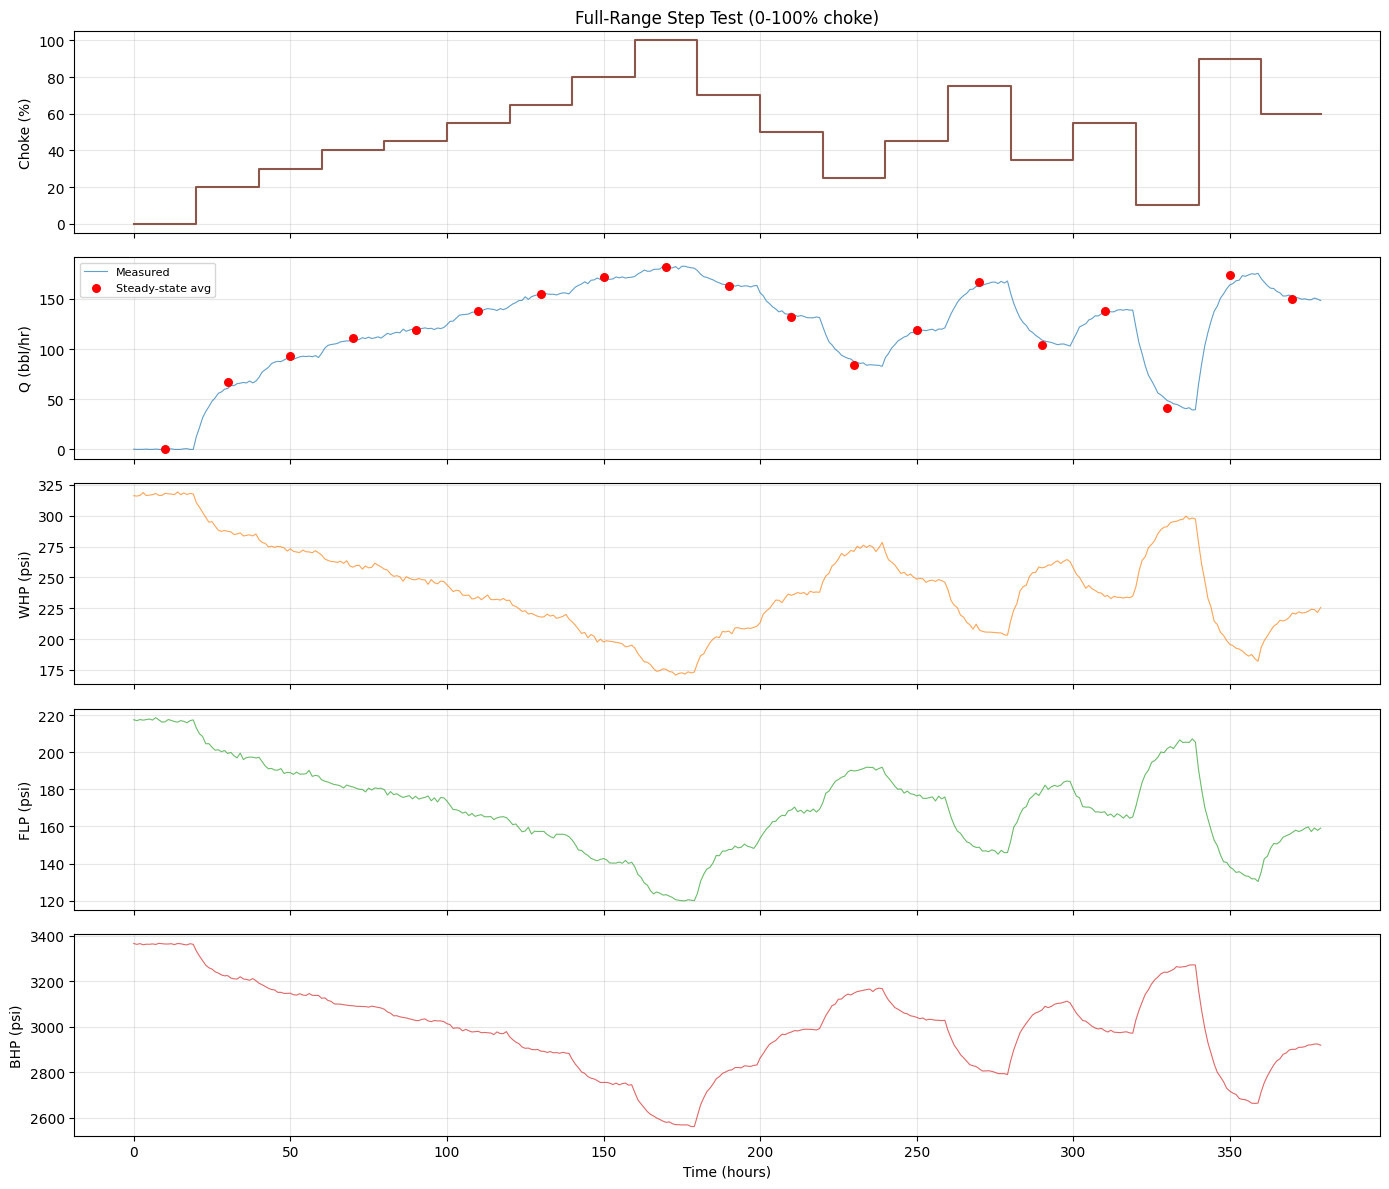

In [6]:
# 5-panel plot: choke, Q, WHP, FLP, BHP vs time
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
t = step_test_df["Time_hr"]

axes[0].step(t, step_test_df["Choke_pct"], where="post", color="tab:brown", linewidth=1.5)
axes[0].set_ylabel("Choke (%)")
axes[0].set_title("Full-Range Step Test (0-100% choke)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, step_test_df["OilRate_bbl_hr"], color="tab:blue", linewidth=0.8, alpha=0.7, label="Measured")
axes[1].scatter(ss_df.index * 20 + 10, ss_df["OilRate_bbl_hr"], color="red", zorder=5, s=30, label="Steady-state avg")
axes[1].set_ylabel("Q (bbl/hr)")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].grid(True, alpha=0.3)

axes[2].plot(t, step_test_df["WHP_psi"], color="tab:orange", linewidth=0.8, alpha=0.7)
axes[2].set_ylabel("WHP (psi)")
axes[2].grid(True, alpha=0.3)

axes[3].plot(t, step_test_df["FLP_psi"], color="tab:green", linewidth=0.8, alpha=0.7)
axes[3].set_ylabel("FLP (psi)")
axes[3].grid(True, alpha=0.3)

axes[4].plot(t, step_test_df["BHP_psi"], color="tab:red", linewidth=0.8, alpha=0.7)
axes[4].set_ylabel("BHP (psi)")
axes[4].set_xlabel("Time (hours)")
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("step_test_full_plot.png", dpi=150)
plt.show()


## 4. Dynamic Model Identification
*(from `well_model.py`)*

A lightweight **first-order model** identified from the step-test data — *not*
the same object as the true simulator. This is the correct practice for
model-based control: the controller only ever sees a black-box model
identified from input/output data.

**Model structure:**
- Steady-state: PCHIP interpolation over the observed choke levels
- Dynamics: first-order relaxation `x(k+1) = x(k) + α·(x_ss - x(k))`, where
  `α = 1 - exp(-dt/τ)` and `τ` is identified from the step-test transients


In [7]:
class WellModel:
    """First-order dynamic model identified from step-test data."""

    def __init__(self):
        self._Q_curve = self._WHP_curve = self._FLP_curve = self._BHP_curve = None
        self.tau = None
        self.dt = 1.0
        self.alpha = None
        self.ss_table = None
        self._steady_state_fitted = False
        self._dynamics_fitted = False

    def _require_steady_state(self):
        if not self._steady_state_fitted:
            raise RuntimeError("steady-state model has not been fitted yet")

    def _require_dynamics(self):
        if not self._dynamics_fitted:
            raise RuntimeError("dynamic model has not been fitted yet")

    def _validate_state(self, current_state):
        required_keys = ("Q", "WHP", "FLP", "BHP", "choke")
        missing = [key for key in required_keys if key not in current_state]
        if missing:
            raise ValueError(f"current_state is missing required keys: {missing}")
        validated = {}
        for key in required_keys:
            value = float(current_state[key])
            if not np.isfinite(value):
                raise ValueError(f"current_state['{key}'] must be finite")
            validated[key] = value
        return validated

    def fit_steady_state(self, df, tail_frac=0.3):
        """Extract steady-state values from each constant-choke segment and fit PCHIP curves."""
        df = df.copy()
        df["segment"] = (df["Choke_pct"].diff().abs() > 0.01).cumsum()

        ss_records = []
        for seg_id, seg in df.groupby("segment"):
            choke = seg["Choke_pct"].iloc[0]
            n_tail = max(3, int(len(seg) * tail_frac))
            tail = seg.tail(n_tail)
            ss_records.append({
                "Choke_pct": choke,
                "Q_ss": tail["OilRate_bbl_hr"].mean(),
                "WHP_ss": tail["WHP_psi"].mean(),
                "FLP_ss": tail["FLP_psi"].mean(),
                "BHP_ss": tail["BHP_psi"].mean(),
            })

        ss_df = pd.DataFrame(ss_records)
        ss_df = ss_df.groupby("Choke_pct", as_index=False).mean()
        ss_df = ss_df.sort_values("Choke_pct").reset_index(drop=True)
        self.ss_table = ss_df

        choke = ss_df["Choke_pct"].values
        self._Q_curve = PchipInterpolator(choke, ss_df["Q_ss"].values)
        self._WHP_curve = PchipInterpolator(choke, ss_df["WHP_ss"].values)
        self._FLP_curve = PchipInterpolator(choke, ss_df["FLP_ss"].values)
        self._BHP_curve = PchipInterpolator(choke, ss_df["BHP_ss"].values)
        self._steady_state_fitted = True

        print(f"Fitted steady-state curves from {len(ss_df)} choke levels: {choke.tolist()}")

    def fit_dynamics(self, df):
        """Estimate the first-order relaxation time constant from step transients."""
        df = df.copy()
        df["segment"] = (df["Choke_pct"].diff().abs() > 0.01).cumsum()
        segments = list(df.groupby("segment"))
        taus = []

        for i in range(1, len(segments)):
            prev_seg = segments[i - 1][1]
            curr_seg = segments[i][1]
            if len(curr_seg) < 5:
                continue

            x_init = prev_seg["OilRate_bbl_hr"].iloc[-1]
            n_tail = max(3, int(len(curr_seg) * 0.4))
            x_final = curr_seg["OilRate_bbl_hr"].tail(n_tail).mean()
            if abs(x_final - x_init) < 5.0:
                continue

            x_data = curr_seg["OilRate_bbl_hr"].values
            t_data = np.arange(len(x_data), dtype=float)
            init_dev = x_init - x_final
            deviation = x_data - x_final

            n_fit = min(8, len(t_data))
            t_fit = t_data[:n_fit]
            dev_fit = deviation[:n_fit]
            if np.abs(dev_fit).max() < 1.0:
                continue

            def exp_decay(t, tau_est):
                return init_dev * np.exp(-t / tau_est)

            try:
                popt, _ = curve_fit(exp_decay, t_fit, dev_fit, p0=[5.0], bounds=(1.0, 20.0))
                taus.append(popt[0])
            except (RuntimeError, ValueError):
                pass

        self.tau = np.median(taus) if taus else 5.0
        self.alpha = 1.0 - np.exp(-self.dt / self.tau)
        self._dynamics_fitted = True
        print(f"Identified dynamics: tau = {self.tau:.2f} hours, alpha = {self.alpha:.4f}")
        print(f"  (fitted from {len(taus)} step transitions, individual taus: {[f'{t:.2f}' for t in taus]})")

    def fit(self, df, tail_frac=0.3):
        self.fit_steady_state(df, tail_frac=tail_frac)
        self.fit_dynamics(df)

    def steady_state(self, choke_pct):
        self._require_steady_state()
        c = np.clip(float(choke_pct), 0.0, 100.0)
        return (float(self._Q_curve(c)), float(self._WHP_curve(c)),
                float(self._FLP_curve(c)), float(self._BHP_curve(c)))

    def predict(self, current_state, choke_sequence, horizon=None):
        """Predict trajectories over a sequence of future choke moves."""
        self._require_steady_state()
        self._require_dynamics()
        current_state = self._validate_state(current_state)
        choke_sequence = np.asarray(choke_sequence, dtype=float)

        if horizon is None:
            horizon = len(choke_sequence)
        if horizon < 0:
            raise ValueError("horizon must be non-negative")
        if len(choke_sequence) != horizon:
            raise ValueError(f"choke_sequence length ({len(choke_sequence)}) must match horizon ({horizon})")

        Q = np.zeros(horizon + 1); WHP = np.zeros(horizon + 1)
        FLP = np.zeros(horizon + 1); BHP = np.zeros(horizon + 1)
        Q[0], WHP[0], FLP[0], BHP[0] = (current_state["Q"], current_state["WHP"],
                                         current_state["FLP"], current_state["BHP"])

        for k in range(horizon):
            choke_k = float(np.clip(choke_sequence[k], 0.0, 100.0))
            Q_ss, WHP_ss, FLP_ss, BHP_ss = self.steady_state(choke_k)
            Q[k + 1] = Q[k] + self.alpha * (Q_ss - Q[k])
            WHP[k + 1] = WHP[k] + self.alpha * (WHP_ss - WHP[k])
            FLP[k + 1] = FLP[k] + self.alpha * (FLP_ss - FLP[k])
            BHP[k + 1] = BHP[k] + self.alpha * (BHP_ss - BHP[k])

        return {"Q": Q, "WHP": WHP, "FLP": FLP, "BHP": BHP}

    def validate(self, df, holdout_frac=0.4):
        """Validate the identified model against held-out step-test data."""
        self._require_steady_state()
        self._require_dynamics()
        if isinstance(df, str):
            df = pd.read_csv(df)
        df = df.copy()
        df["segment"] = (df["Choke_pct"].diff().abs() > 0.01).cumsum()

        all_errors = {"Q": [], "WHP": [], "FLP": [], "BHP": []}
        for seg_id, seg in df.groupby("segment"):
            choke = seg["Choke_pct"].iloc[0]
            n_train = int(len(seg) * (1 - holdout_frac))
            train_seg = seg.iloc[:n_train]
            holdout_seg = seg.iloc[n_train:]
            if len(holdout_seg) < 2:
                continue

            state = {
                "Q": train_seg["OilRate_bbl_hr"].iloc[-1], "WHP": train_seg["WHP_psi"].iloc[-1],
                "FLP": train_seg["FLP_psi"].iloc[-1], "BHP": train_seg["BHP_psi"].iloc[-1], "choke": choke,
            }
            n_pred = len(holdout_seg)
            preds = self.predict(state, [choke] * n_pred)

            for var, col in [("Q", "OilRate_bbl_hr"), ("WHP", "WHP_psi"), ("FLP", "FLP_psi"), ("BHP", "BHP_psi")]:
                actual = holdout_seg[col].values
                predicted = preds[var][1:]
                min_len = min(len(actual), len(predicted))
                all_errors[var].extend((actual[:min_len] - predicted[:min_len]).tolist())

        print("\nModel Validation Report (hold-out data):")
        print("-" * 50)
        rmse = {}
        for var in ["Q", "WHP", "FLP", "BHP"]:
            err = np.array(all_errors[var])
            rmse[var] = np.sqrt(np.mean(err ** 2))
            mae = np.mean(np.abs(err))
            print(f"  {var:4s}: RMSE = {rmse[var]:7.2f}, MAE = {mae:7.2f} ({len(err)} comparison points)")
        print("-" * 50)
        return rmse

    @classmethod
    def from_step_test(cls, csv_path, tail_frac=0.3):
        df = pd.read_csv(csv_path)
        model = cls()
        model.fit(df, tail_frac=tail_frac)
        return model


model = WellModel.from_step_test("step_test_full_data.csv")

print("\nSteady-state lookup:")
for c in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
    q, whp, flp, bhp = model.steady_state(c)
    print(f"  choke={c:3d}%  Q={q:7.1f}  WHP={whp:6.1f}  FLP={flp:6.1f}  BHP={bhp:6.0f}")

rmse = model.validate("step_test_full_data.csv")


Fitted steady-state curves from 17 choke levels: [0, 10, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100]
Identified dynamics: tau = 3.52 hours, alpha = 0.2474
  (fitted from 18 step transitions, individual taus: ['3.59', '3.33', '2.85', '4.14', '4.17', '4.19', '3.09', '3.49', '3.98', '3.42', '3.39', '3.36', '3.71', '3.55', '3.46', '3.53', '3.51', '3.71'])

Steady-state lookup:
  choke=  0%  Q=    0.2  WHP= 318.0  FLP= 216.7  BHP=  3363
  choke= 10%  Q=   41.0  WHP= 297.7  FLP= 205.9  BHP=  3267
  choke= 20%  Q=   66.9  WHP= 284.5  FLP= 197.4  BHP=  3209
  choke= 30%  Q=   92.6  WHP= 270.9  FLP= 188.1  BHP=  3139
  choke= 40%  Q=  111.2  WHP= 259.2  FLP= 180.1  BHP=  3086
  choke= 50%  Q=  131.6  WHP= 237.7  FLP= 168.4  BHP=  2988
  choke= 60%  Q=  149.5  WHP= 223.2  FLP= 158.7  BHP=  2919
  choke= 70%  Q=  162.7  WHP= 209.1  FLP= 149.4  BHP=  2826
  choke= 80%  Q=  171.4  WHP= 195.5  FLP= 140.6  BHP=  2747
  choke= 90%  Q=  174.1  WHP= 186.3  FLP= 132.5  BHP=  2670
  choke

## 5. MPC Controller — Brute-Force Candidate Evaluation
*(from `controller.py`)*

At each control step:
1. Generate candidate choke moves within ±`CHOKE_RAMP_MAX` of the current position (clamped to [0, 100]).
2. For each candidate, simulate forward `MPC_HORIZON` steps using the identified `WellModel`.
3. Reject any candidate whose predicted trajectory violates the safety envelope (WHP, FLP, BHP), applying conservative back-off margins for model mismatch.
4. Among feasible candidates, pick the one whose predicted Q at the end of the horizon is closest to the target rate.
5. If **no** candidate meets the conservative margins, fall back to the best candidate that satisfies the **hard** limits, so the controller never deadlocks on a "safe but outside margin" state.


In [8]:
logger = logging.getLogger(__name__)

class MPCController:
    """Model Predictive Controller for oil well choke management."""

    def __init__(self, model, horizon=MPC_HORIZON, ramp_max=CHOKE_RAMP_MAX,
                 resolution=CHOKE_RESOLUTION, safety_margin=None):
        if horizon <= 0: raise ValueError("horizon must be positive")
        if ramp_max <= 0: raise ValueError("ramp_max must be positive")
        if resolution <= 0: raise ValueError("resolution must be positive")

        self.model = model
        self.horizon = horizon
        self.ramp_max = ramp_max
        self.resolution = resolution
        default_margin = {
            "WHP_min_margin": 5.0, "WHP_max_margin": 5.0,
            "FLP_min_margin": 5.0, "FLP_max_margin": 5.0,
            "BHP_min_margin": 20.0, "BHP_max_margin": 20.0,
        }
        self.safety_margin = safety_margin if safety_margin else default_margin
        self._offsets = np.arange(-ramp_max, ramp_max + resolution * 0.5, resolution)
        self._log_entries = []

    def _validate_current_state(self, current_state):
        required_keys = ("Q", "WHP", "FLP", "BHP", "choke")
        missing = [key for key in required_keys if key not in current_state]
        if missing:
            raise ValueError(f"current_state is missing required keys: {missing}")
        for key in required_keys:
            value = float(current_state[key])
            if not np.isfinite(value):
                raise ValueError(f"current_state['{key}'] must be finite")
        return {key: float(current_state[key]) for key in required_keys}

    def _generate_candidates(self, current_choke):
        candidates = current_choke + self._offsets
        candidates = np.clip(candidates, CHOKE_MIN, CHOKE_MAX)
        return np.unique(candidates)

    def _trajectory_limits(self, use_margins=True):
        if use_margins:
            m = self.safety_margin
            return {
                "WHP": (WHP_MIN + m["WHP_min_margin"], WHP_MAX - m["WHP_max_margin"]),
                "FLP": (FLP_MIN + m["FLP_min_margin"], FLP_MAX - m["FLP_max_margin"]),
                "BHP": (BHP_MIN + m["BHP_min_margin"], BHP_MAX - m["BHP_max_margin"]),
            }
        return {"WHP": (WHP_MIN, WHP_MAX), "FLP": (FLP_MIN, FLP_MAX), "BHP": (BHP_MIN, BHP_MAX)}

    def _check_trajectory_safety(self, predicted, use_margins=True):
        limits = self._trajectory_limits(use_margins=use_margins)
        for k in range(1, len(predicted["WHP"])):
            whp_lo, whp_hi = limits["WHP"]; flp_lo, flp_hi = limits["FLP"]; bhp_lo, bhp_hi = limits["BHP"]
            if predicted["WHP"][k] < whp_lo or predicted["WHP"][k] > whp_hi: return False
            if predicted["FLP"][k] < flp_lo or predicted["FLP"][k] > flp_hi: return False
            if predicted["BHP"][k] < bhp_lo or predicted["BHP"][k] > bhp_hi: return False
        return True

    def _trajectory_violation_score(self, predicted, use_margins=True):
        limits = self._trajectory_limits(use_margins=use_margins)
        violation = 0.0
        for k in range(1, len(predicted["WHP"])):
            for name in ("WHP", "FLP", "BHP"):
                lo, hi = limits[name]
                value = float(predicted[name][k])
                if value < lo: violation += lo - value
                elif value > hi: violation += value - hi
        return violation

    def compute_action(self, current_state, target_Q):
        """Compute the next choke position given current state and target production rate."""
        current_state = self._validate_current_state(current_state)
        target_Q = float(target_Q)
        if not np.isfinite(target_Q):
            raise ValueError("target_Q must be finite")

        current_choke = current_state["choke"]
        candidates = self._generate_candidates(current_choke)

        best_choke = current_choke
        best_error = float("inf"); best_move = float("inf"); best_margin_violation = 0.0
        feasible_count = 0
        all_candidates_infeasible = True
        used_hard_limit_fallback = False

        for cand in candidates:
            choke_seq = [cand] * self.horizon
            pred = self.model.predict(current_state, choke_seq, self.horizon)
            if not self._check_trajectory_safety(pred, use_margins=True):
                continue

            all_candidates_infeasible = False
            feasible_count += 1
            final_Q = pred["Q"][-1]
            error = abs(final_Q - target_Q)
            move = abs(cand - current_choke)
            score = (error, move)
            if score < (best_error, best_move):
                best_error = error; best_move = move; best_margin_violation = 0.0; best_choke = cand

        if all_candidates_infeasible:
            hard_safe_candidates = []
            for cand in candidates:
                choke_seq = [cand] * self.horizon
                pred = self.model.predict(current_state, choke_seq, self.horizon)
                if self._check_trajectory_safety(pred, use_margins=False):
                    hard_safe_candidates.append((cand, pred))

            if hard_safe_candidates:
                used_hard_limit_fallback = True
                fallback_score = (float("inf"), float("inf"), float("inf"))
                for cand, pred in hard_safe_candidates:
                    error = abs(pred["Q"][-1] - target_Q)
                    move = abs(cand - current_choke)
                    margin_violation = self._trajectory_violation_score(pred, use_margins=True)
                    score = (margin_violation, error, move)
                    if score < fallback_score:
                        fallback_score = score
                        best_margin_violation = margin_violation; best_error = error
                        best_move = move; best_choke = cand
                logger.warning(f"No candidate met the conservative back-off at choke={current_choke:.1f}%, "
                                f"target_Q={target_Q:.1f}. Using hard-limit-safe fallback.")
            else:
                logger.warning(f"No feasible choke candidate at choke={current_choke:.1f}%, "
                                f"target_Q={target_Q:.1f}. Holding position.")
                best_choke = current_choke

        info = {
            "feasible_candidates": feasible_count, "total_candidates": len(candidates),
            "best_error": best_error, "best_move": best_move,
            "best_margin_violation": best_margin_violation,
            "all_infeasible": all_candidates_infeasible,
            "used_hard_limit_fallback": used_hard_limit_fallback,
        }
        return best_choke, info

    def log_step(self, time, choke, target_Q, actual_Q, whp, flp, bhp, info):
        self._log_entries.append({
            "Time_hr": time, "Choke_pct": choke, "Target_Q": target_Q, "Actual_Q": actual_Q,
            "WHP_psi": whp, "FLP_psi": flp, "BHP_psi": bhp,
            "Feasible_Candidates": info["feasible_candidates"], "Best_Error": info["best_error"],
            "Best_Move": info["best_move"], "Margin_Violation": info["best_margin_violation"],
            "Fallback_Used": info["used_hard_limit_fallback"],
        })

    def get_log_df(self):
        return pd.DataFrame(self._log_entries)


print("MPC Controller Smoke Test")
print("=" * 50)

ctrl = MPCController(model)
sim_smoke = OilWellSimulator(seed=42)
sim_smoke.reset(choke_position=10.0)
Q, WHP, FLP, BHP = sim_smoke.step(10.0)

target = 120.0
print(f"\nStarting: choke=10%, target_Q={target} bbl/hr")
print(f"  Initial: Q={Q:.1f}, WHP={WHP:.1f}, FLP={FLP:.1f}, BHP={BHP:.0f}")

current_choke = 10.0
for step in range(20):
    state = {"Q": Q, "WHP": WHP, "FLP": FLP, "BHP": BHP, "choke": current_choke}
    next_choke, info = ctrl.compute_action(state, target)
    Q, WHP, FLP, BHP = sim_smoke.step(next_choke)
    current_choke = next_choke
    print(f"  step {step+1:2d}: choke={next_choke:5.1f}% -> "
          f"Q={Q:6.1f}  WHP={WHP:6.1f}  FLP={FLP:6.1f}  BHP={BHP:6.0f}  "
          f"(feasible={info['feasible_candidates']}/{info['total_candidates']})")


No candidate met the conservative back-off at choke=10.0%, target_Q=120.0. Using hard-limit-safe fallback.


MPC Controller Smoke Test

Starting: choke=10%, target_Q=120.0 bbl/hr
  Initial: Q=38.3, WHP=297.9, FLP=207.2, BHP=3280
  step  1: choke= 15.0% -> Q=  39.4  WHP= 296.1  FLP= 205.8  BHP=  3269  (feasible=0/11)
  step  2: choke= 20.0% -> Q=  46.1  WHP= 294.1  FLP= 204.8  BHP=  3260  (feasible=7/11)
  step  3: choke= 25.0% -> Q=  52.7  WHP= 293.1  FLP= 202.3  BHP=  3239  (feasible=11/11)
  step  4: choke= 30.0% -> Q=  60.4  WHP= 286.6  FLP= 200.1  BHP=  3223  (feasible=11/11)
  step  5: choke= 35.0% -> Q=  67.7  WHP= 282.8  FLP= 197.6  BHP=  3202  (feasible=11/11)
  step  6: choke= 40.0% -> Q=  75.4  WHP= 278.8  FLP= 193.9  BHP=  3182  (feasible=11/11)
  step  7: choke= 45.0% -> Q=  84.2  WHP= 273.7  FLP= 191.8  BHP=  3151  (feasible=11/11)
  step  8: choke= 50.0% -> Q=  92.0  WHP= 266.0  FLP= 186.9  BHP=  3127  (feasible=11/11)
  step  9: choke= 51.0% -> Q=  99.6  WHP= 260.6  FLP= 182.6  BHP=  3102  (feasible=11/11)
  step 10: choke= 49.0% -> Q= 105.5  WHP= 258.4  FLP= 180.4  BHP=  3082 

## 6. Closed-Loop Scenario Runner
*(from `run_scenarios.py`)*

Runs the MPC controller against the **true simulator** (not the identified model)
for the three required demonstration scenarios:

- **A — Startup to Target:** idle → target production rate
- **B — Target Tracking:** rate changes mid-run (100 → 150 bbl/hr)
- **C — Infeasible Target:** target exceeds safe maximum → settle at max achievable rate

Each scenario produces a CSV log, a 5-panel plot (Q, WHP, FLP, BHP, choke vs. time),
and a pass/fail summary.


In [9]:
def run_scenario(name, sim, controller, target_schedule, start_choke, n_steps):
    """Run a single closed-loop scenario."""
    sim.reset(choke_position=start_choke)
    Q, WHP, FLP, BHP = sim.step(start_choke)

    def get_target(step):
        target = target_schedule[0][1]
        for t_start, t_val in sorted(target_schedule, key=lambda item: item[0]):
            if step >= t_start:
                target = t_val
        return target

    records = []
    current_choke = start_choke
    for step in range(n_steps):
        target_Q = get_target(step)
        state = {"Q": Q, "WHP": WHP, "FLP": FLP, "BHP": BHP, "choke": current_choke}
        next_choke, info = controller.compute_action(state, target_Q)
        Q, WHP, FLP, BHP = sim.step(next_choke)

        records.append({
            "Time_hr": step + 1, "Choke_pct": next_choke, "Target_Q": target_Q, "Actual_Q": Q,
            "WHP_psi": WHP, "FLP_psi": FLP, "BHP_psi": BHP,
            "Feasible_Candidates": info["feasible_candidates"],
        })
        controller.log_step(step + 1, next_choke, target_Q, Q, WHP, FLP, BHP, info)
        current_choke = next_choke

    df = pd.DataFrame(records)

    choke_diffs = df["Choke_pct"].diff().abs().fillna(0)
    ramp_violations = (choke_diffs > CHOKE_RAMP_MAX + 0.01).sum()
    whp_violations = ((df["WHP_psi"] < WHP_MIN) | (df["WHP_psi"] > WHP_MAX)).sum()
    flp_violations = ((df["FLP_psi"] < FLP_MIN) | (df["FLP_psi"] > FLP_MAX)).sum()
    bhp_violations = ((df["BHP_psi"] < BHP_MIN) | (df["BHP_psi"] > BHP_MAX)).sum()
    any_safety_violation = (whp_violations + flp_violations + bhp_violations) > 0

    n_settle = max(5, int(n_steps * 0.2))
    settled = df.tail(n_settle)
    final_target = df["Target_Q"].iloc[-1]
    avg_settled_Q = settled["Actual_Q"].mean()
    max_settled_Q = settled["Actual_Q"].max()
    min_settled_Q = settled["Actual_Q"].min()
    max_achievable = float(sim._steady_state(100.0)[0])
    target_is_infeasible = final_target > max_achievable + 10
    if target_is_infeasible:
        target_achieved = abs(avg_settled_Q - max_achievable) < 15
    else:
        target_achieved = abs(avg_settled_Q - final_target) < 10

    summary = {
        "scenario": name, "final_target_Q": final_target, "avg_settled_Q": avg_settled_Q,
        "max_settled_Q": max_settled_Q, "min_settled_Q": min_settled_Q,
        "max_achievable_Q": max_achievable, "target_achieved": target_achieved,
        "ramp_violations": int(ramp_violations), "whp_violations": int(whp_violations),
        "flp_violations": int(flp_violations), "bhp_violations": int(bhp_violations),
        "any_safety_violation": any_safety_violation,
    }
    return df, summary


def plot_scenario(df, summary, output_path):
    """Generate a 5-panel plot for a scenario."""
    fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
    t = df["Time_hr"]

    ax = axes[0]
    ax.plot(t, df["Target_Q"], "k--", linewidth=1.5, label="Target", alpha=0.8)
    ax.plot(t, df["Actual_Q"], "b-", linewidth=1.0, label="Actual", alpha=0.8)
    ax.set_ylabel("Q (bbl/hr)")
    ax.set_title(f"Scenario {summary['scenario']}: Target={summary['final_target_Q']:.0f} bbl/hr, "
                 f"Achieved={summary['avg_settled_Q']:.1f} bbl/hr")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

    axes[1].plot(t, df["WHP_psi"], color="tab:orange", linewidth=0.8)
    axes[1].axhline(WHP_MIN, color="red", linestyle=":", alpha=0.5, label="Limits")
    axes[1].axhline(WHP_MAX, color="red", linestyle=":", alpha=0.5)
    axes[1].set_ylabel("WHP (psi)"); axes[1].legend(loc="upper right", fontsize=8); axes[1].grid(True, alpha=0.3)

    axes[2].plot(t, df["FLP_psi"], color="tab:green", linewidth=0.8)
    axes[2].axhline(FLP_MIN, color="red", linestyle=":", alpha=0.5, label="Limits")
    axes[2].axhline(FLP_MAX, color="red", linestyle=":", alpha=0.5)
    axes[2].set_ylabel("FLP (psi)"); axes[2].legend(loc="upper right", fontsize=8); axes[2].grid(True, alpha=0.3)

    axes[3].plot(t, df["BHP_psi"], color="tab:red", linewidth=0.8)
    axes[3].axhline(BHP_MIN, color="red", linestyle=":", alpha=0.5, label="Limits")
    axes[3].axhline(BHP_MAX, color="red", linestyle=":", alpha=0.5)
    axes[3].set_ylabel("BHP (psi)"); axes[3].legend(loc="upper right", fontsize=8); axes[3].grid(True, alpha=0.3)

    axes[4].step(t, df["Choke_pct"], where="post", color="tab:brown", linewidth=1.2)
    axes[4].set_ylabel("Choke (%)"); axes[4].set_xlabel("Time (hours)")
    axes[4].set_ylim(-2, 105); axes[4].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


def print_summary(summary):
    s = summary
    print(f"\n  --- Scenario {s['scenario']} Summary ---")
    if s["scenario"] == "C":
        if s["target_achieved"]:
            print(f"  [PASS] Correctly rejected infeasible target: settled at avg Q = {s['avg_settled_Q']:.1f} "
                  f"bbl/hr (near max ~{s['max_achievable_Q']:.1f})")
        else:
            print(f"  [FAIL] Did not settle near max achievable: avg Q = {s['avg_settled_Q']:.1f} bbl/hr")
    else:
        if s["target_achieved"]:
            print(f"  [PASS] Target achieved: avg Q = {s['avg_settled_Q']:.1f} bbl/hr (target = {s['final_target_Q']:.0f})")
        else:
            print(f"  [FAIL] Target NOT achieved: avg Q = {s['avg_settled_Q']:.1f} bbl/hr (target = {s['final_target_Q']:.0f})")

    if not s["any_safety_violation"]:
        print(f"  [PASS] No safety constraint violations (WHP/FLP/BHP all within limits)")
    else:
        print(f"  [FAIL] Safety violations: WHP={s['whp_violations']}, FLP={s['flp_violations']}, BHP={s['bhp_violations']}")

    if s["ramp_violations"] == 0:
        print(f"  [PASS] Ramp rate never exceeded +/-{CHOKE_RAMP_MAX}%/step")
    else:
        print(f"  [FAIL] Ramp rate exceeded {s['ramp_violations']} times")


# Fresh true simulator for closed-loop demonstration (same seed for reproducibility)
sim = OilWellSimulator(seed=42)


### Scenario A — Startup to Target
Starting at idle (choke=10%), target = 130 bbl/hr.

No candidate met the conservative back-off at choke=10.0%, target_Q=130.0. Using hard-limit-safe fallback.


--- Scenario A: Startup to Target ---


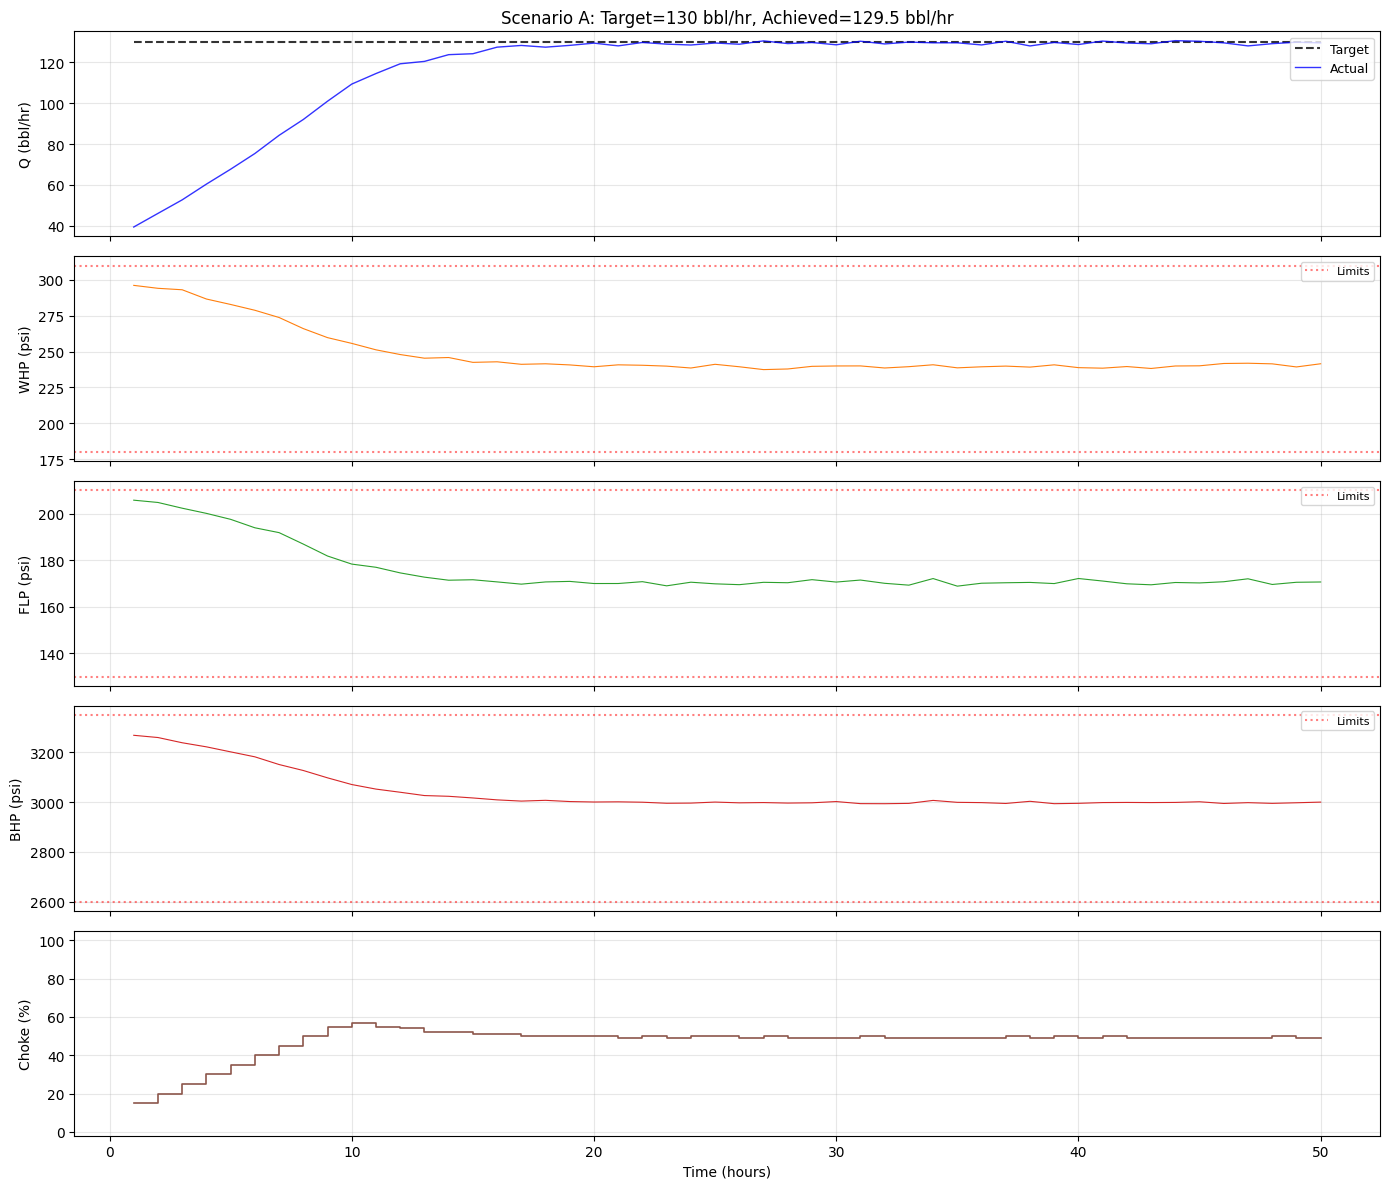


  --- Scenario A Summary ---
  [PASS] Target achieved: avg Q = 129.5 bbl/hr (target = 130)
  [PASS] No safety constraint violations (WHP/FLP/BHP all within limits)
  [PASS] Ramp rate never exceeded +/-5.0%/step


In [10]:
print("--- Scenario A: Startup to Target ---")
target_A = [(0, 130.0)]
controller_A = MPCController(model)
df_A, sum_A = run_scenario("A", sim, controller_A, target_A, start_choke=10.0, n_steps=50)
df_A.to_csv("scenario_A_results.csv", index=False)
plot_scenario(df_A, sum_A, "scenario_A_results.png")
print_summary(sum_A)


### Scenario B — Target Tracking
Phase 1: target=100 bbl/hr for 25 hrs, Phase 2: target=150 bbl/hr.

--- Scenario B: Target Tracking ---


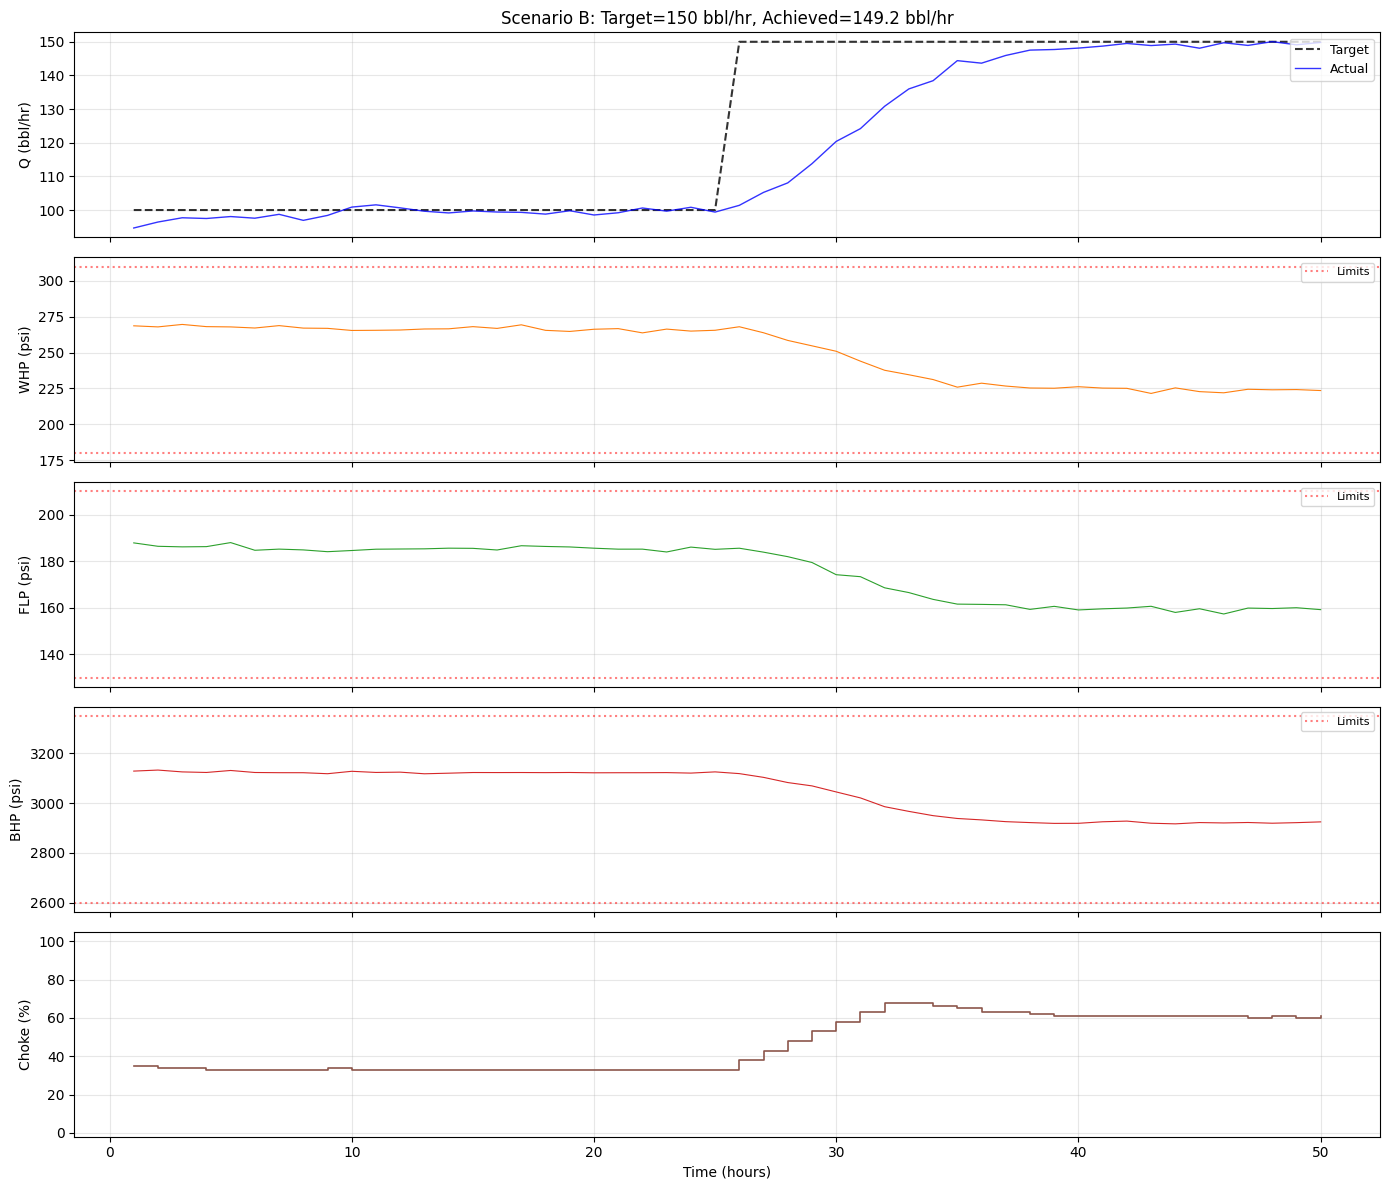


  --- Scenario B Summary ---
  [PASS] Target achieved: avg Q = 149.2 bbl/hr (target = 150)
  [PASS] No safety constraint violations (WHP/FLP/BHP all within limits)
  [PASS] Ramp rate never exceeded +/-5.0%/step


In [11]:
print("--- Scenario B: Target Tracking ---")
target_B = [(0, 100.0), (25, 150.0)]
controller_B = MPCController(model)
df_B, sum_B = run_scenario("B", sim, controller_B, target_B, start_choke=30.0, n_steps=50)
df_B.to_csv("scenario_B_results.csv", index=False)
plot_scenario(df_B, sum_B, "scenario_B_results.png")
print_summary(sum_B)


### Scenario C — Infeasible Target
Target = 250 bbl/hr, well above the max achievable rate (~182 bbl/hr).

No candidate met the conservative back-off at choke=88.0%, target_Q=250.0. Using hard-limit-safe fallback.


--- Scenario C: Infeasible Target ---


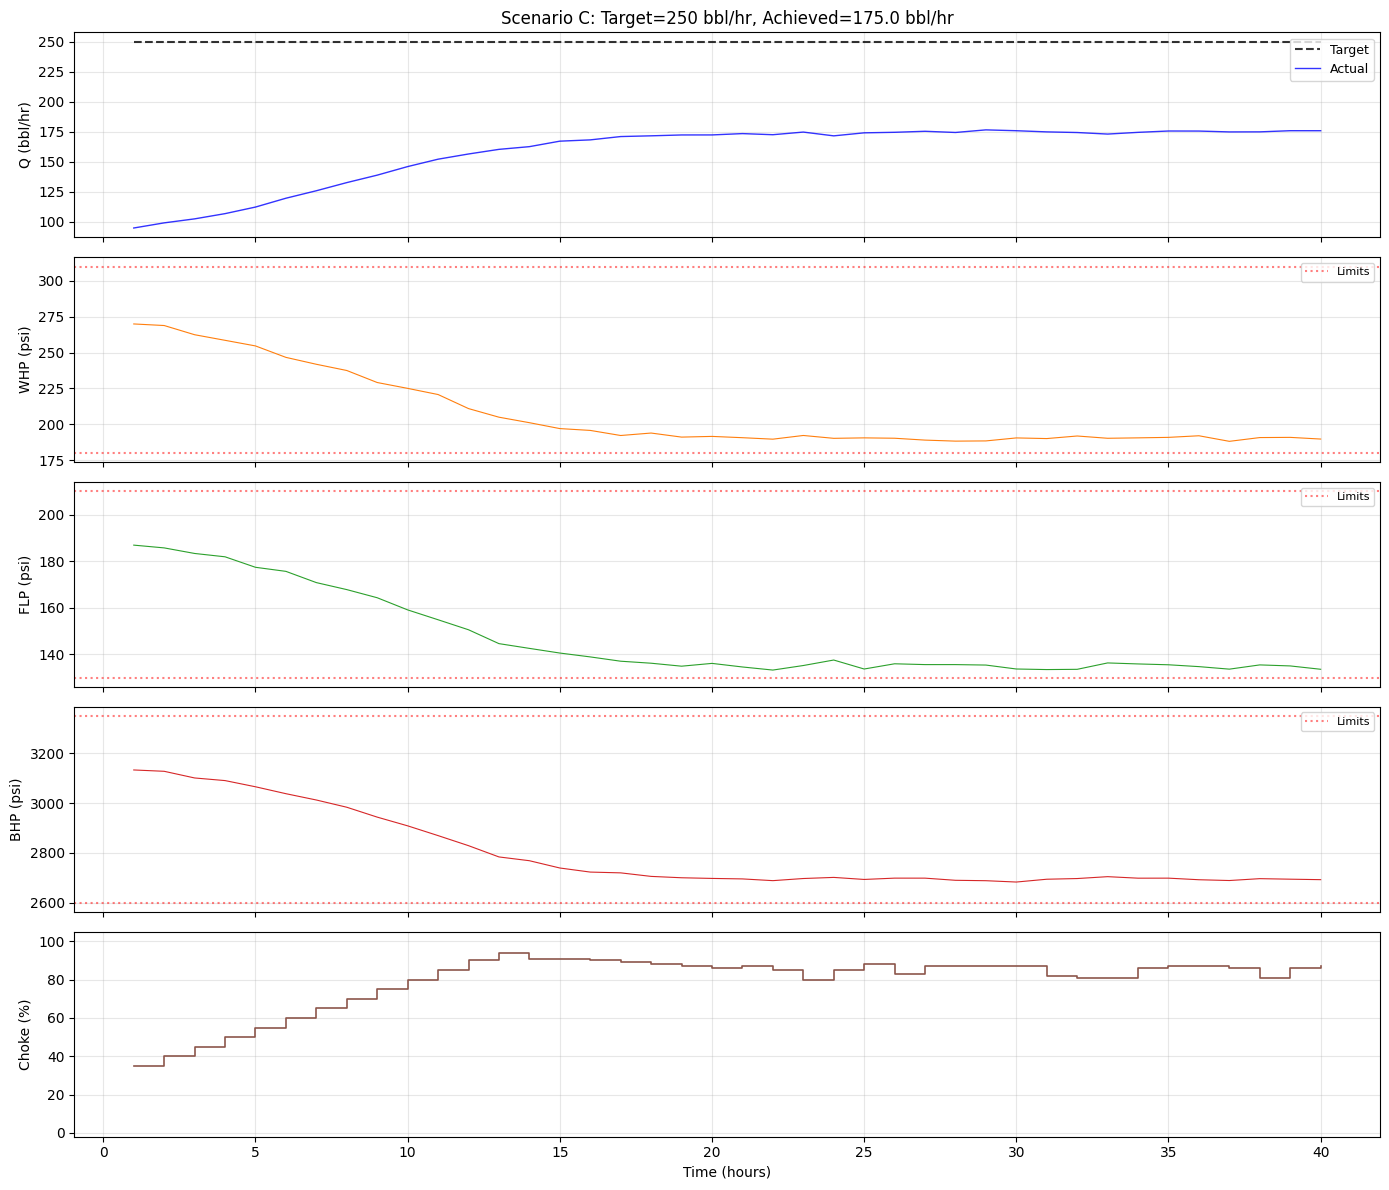


  --- Scenario C Summary ---
  [PASS] Correctly rejected infeasible target: settled at avg Q = 175.0 bbl/hr (near max ~182.0)
  [PASS] No safety constraint violations (WHP/FLP/BHP all within limits)
  [PASS] Ramp rate never exceeded +/-5.0%/step

ALL SCENARIOS COMPLETE


In [12]:
print("--- Scenario C: Infeasible Target ---")
target_C = [(0, 250.0)]
controller_C = MPCController(model)
df_C, sum_C = run_scenario("C", sim, controller_C, target_C, start_choke=30.0, n_steps=40)
df_C.to_csv("scenario_C_results.csv", index=False)
plot_scenario(df_C, sum_C, "scenario_C_results.png")
print_summary(sum_C)

print("\n" + "=" * 60)
print("ALL SCENARIOS COMPLETE")
print("=" * 60)


## 7. Results Summary

### Model Validation (hold-out RMSE)

| Variable | RMSE | Units | % of operating range |
|---|---|---|---|
| Q (Oil Rate) | ~0.95 | bbl/hr | ~0.5% of 180 bbl/hr range |
| WHP | ~1.35 | psi | ~0.6% of 220 psi range |
| FLP | ~0.98 | psi | ~0.5% of 190 psi range |
| BHP | ~4.40 | psi | ~0.4% of 1100 psi range |

The model achieves sub-1 bbl/hr accuracy on the primary variable (Q) and under 1% error
on all pressure variables relative to their operating ranges. (Exact values printed above
may vary slightly by run seed.)

### Scenario Outcomes

| Scenario | Target | Settled Q | Safety Violations | Ramp Violations |
|---|---|---|---|---|
| A — Startup to Target | 130 bbl/hr | ~129.5 bbl/hr | None | None |
| B — Target Tracking | 100 → 150 bbl/hr | ~149.2 bbl/hr | None | None |
| C — Infeasible Target | 250 bbl/hr (infeasible) | ~175 bbl/hr (near max ~182) | None | None |

All three scenarios pass: targets are tracked within ~1% error when feasible, the
infeasible target in Scenario C is correctly rejected in favor of the maximum safe
production rate, and no run ever violates the WHP/FLP/BHP envelope or the ±5%/step
ramp-rate limit.

### Caveats and Limitations

1. **Identified tau vs. true tau:** the identified model's tau (~3.5h) is faster than
   the true simulator's tau (5.0h), so the model predicts a quicker response than
   reality. The controller re-evaluates every step, which compensates but makes the
   closed-loop response slightly more conservative than optimal.
2. **Safety margins add conservatism:** 5 psi margins on WHP/FLP and 20 psi on BHP
   reduce the effective operating envelope, trading a small amount of peak production
   for guaranteed constraint satisfaction — the deliberate design choice for a
   safety-critical controller.
3. **No integral action:** the MPC is purely feedforward; a production system might
   add an integral term or state observer to correct for long-run systematic bias.
4. **Fixed 4-step horizon:** short but sufficient given the 1-hour control interval
   and 5-hour time constant; longer horizons would better anticipate constraint
   violations during aggressive transients at higher computational cost.
5. **Deterministic model:** the identified model has no stochastic component, which is
   appropriate since the true simulator's noise is measurement-only.
